## Lab Assignment 4 

Title: Data Analytics I 
PROBLEM STATEMENT: 
 
Create a Linear Regression Model using Python/R to predict home prices using Boston Housing Dataset 
(https://www.kaggle.com/c/boston-housing). The Boston Housing dataset contains information about various 
houses in Boston through different parameters. There are 506 samples and 14 feature variables in this dataset. 

In [1]:
# Exp4.py
!pip install pandas matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import all the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Load the dataset and check the data 
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


| Column | Description |
|---|---|
| crim | Per capita crime rate by town |
| zn | Residential land zoned for large lots |
| indus | Proportion of non-retail business acres |
| chas | Charles River dummy variable (1 if near river, else 0) |
| nox | Nitric oxide concentration |
| rm | Average number of rooms per dwelling |
| age | Proportion of old owner-occupied units |
| dis | Distance to employment centers |
| rad | Accessibility to radial highways |
| tax | Property tax rate |
| ptratio | Pupil-teacher ratio by town |
| b | Proportion related to Black population index |
| lstat | Percentage of lower status population |
| medv | Median value of owner-occupied homes |

In [4]:
# Perform train test split
X = df.drop('medv', axis=1)
y = df['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Create model variable and train the model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
# Perform prediction and calculate error
y_pred = model.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")

MSE: 24.29
R2 Score: 0.67


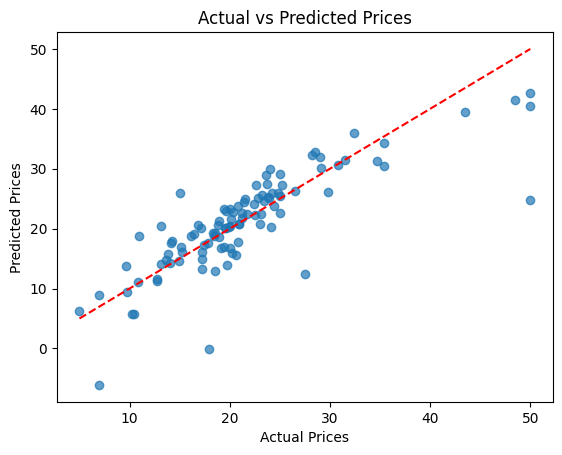

In [7]:
# Plot Actual & Predicted rpice with linear regression line
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [8]:
sample_data = X_test.iloc[0:1]

predicted_price = model.predict(sample_data)

print("Predicted House Price:", predicted_price[0])
print("Actual House Price:", y_test.iloc[0])

Predicted House Price: 28.9967236198249
Actual House Price: 23.6
